# Titanic Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to perform an Exploratory Data Analysis (EDA) on the Titanic dataset to identify factors that influenced passenger survival during the Titanic disaster.

## Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

# **Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic/train.csv')

# **Dataset Inspection**

In [ ]:
df.info()
print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         

# **Data Cleaning**

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns=["Cabin"], inplace=True, errors="ignore")

In [ ]:
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())


Missing Values After Cleaning:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# **Analysis Questions**

**1.Survival Rate by Age Group**

In [ ]:
bins = [0, 12, 19, 35, 60, 100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [ ]:
age_survival = (
    df.groupby("Age_Group")["Survived"]
      .mean() * 100).round(2)

print("Survival Rate by Age Group:\n")
print(age_survival)

best_age_group = age_survival.idxmax()

print(
    f"\nInsight: {best_age_group} passengers had the highest survival rate."
)

Survival Rate by Age Group:

Age_Group
Child          57.97
Teen           41.05
Young Adult    35.29
Adult          40.00
Senior         22.73
Name: Survived, dtype: float64

Insight: Child passengers had the highest survival rate.


/tmp/ipykernel_3446/1624596419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Survived"]


**2.Survival Rate by Embarkation Port**

In [ ]:
embark_survival = (
    df.groupby("Embarked")["Survived"]
      .mean() * 100).round(2)

print("Survival Rate by Embarkation Port:\n")
print(embark_survival)

best_port = embark_survival.idxmax()

print(
    f"\nInsight: Passengers embarking from {best_port} had the highest survival rate."
)

Survival Rate by Embarkation Port:

Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64

Insight: Passengers embarking from C had the highest survival rate.


**3.Survival Rate by Family Size**

In [ ]:
df["Family_Size"] = (
    df["SibSp"] +
    df["Parch"] +
    1
)

In [ ]:
family_survival = (
    df.groupby("Family_Size")["Survived"]
      .mean() * 100).round(2)

print("Survival Rate by Family Size:\n")
print(family_survival)

best_family = family_survival.idxmax()

print(f"\nInsight: Family size {best_family} had the highest survival rate.")

Survival Rate by Family Size:

Family_Size
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64

Insight: Family size 4 had the highest survival rate.


# **Visualizations**

**1.Age Distribution Histogram**

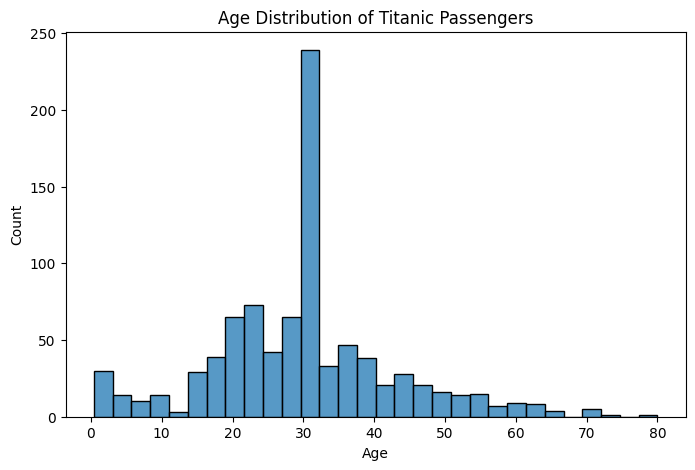

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30
)

plt.title("Age Distribution of Titanic Passengers")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

**2.Correlation Heatmap**

In [ ]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

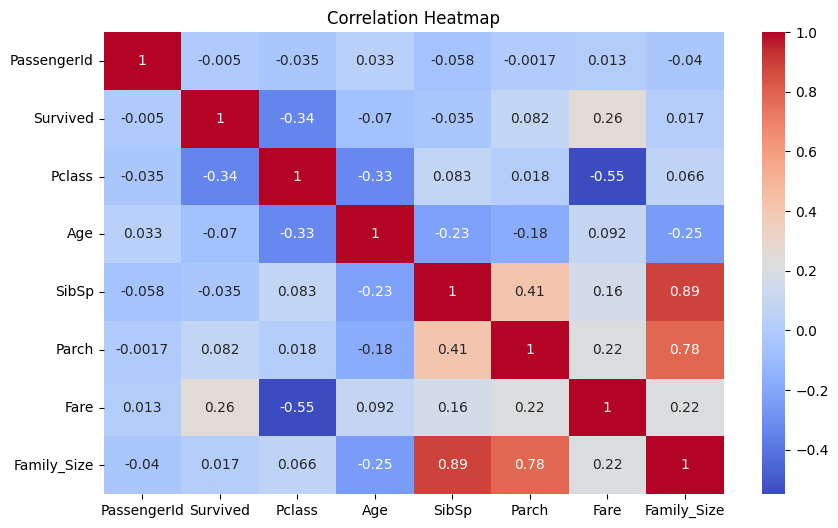

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

**3.Survival by Family Size**

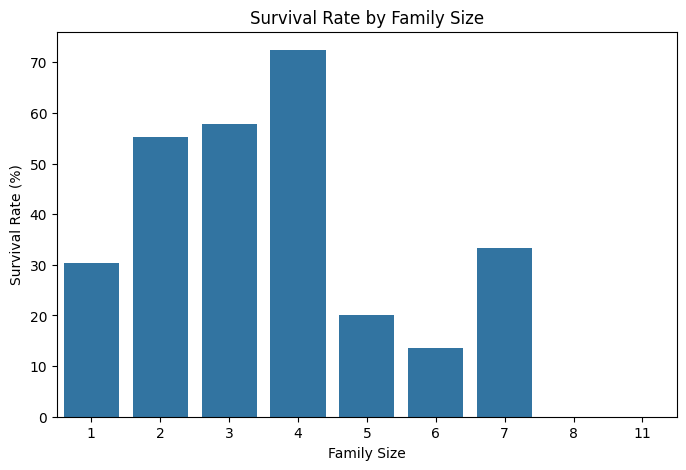

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")

plt.xlabel("Family Size")

plt.ylabel("Survival Rate (%)")

plt.show()